# Change Detector read-out mode or the spectrograph sampling

You can change the way the detector will behave or the properties of the spectrograph.

`LazuliTarget` has top-level methods to do basic changes, but everything is customable going down to the `slicersim.Simulation` object (the `LazuliTarget.simulation` attributed).

In this notebook, let's focus on the top level changes one may want to do.

**For the detector:**

  - the number of frame per group
  - the maximum number of group allowed per ramp
  - manually set the whole configuration

**For the spectrograph:**

  - the spaxel sampling (fine or medium)
  - manually set the sampling

In [1]:
import slicersim

## let's load a calspec star

Let's load a GD-71 like star but with a mag=22 in lssti band.

In [2]:
lazuli_star = slicersim.LazuliCalSpec("gd71", mag=22, band="lssti")

In [3]:
_ = lazuli_star.setup_to_snr(30, lbda_range=[4000, 7000])

In [4]:
lazuli_star.get_exposure_time()

5795.84

In [5]:
lbda, flux, variance = lazuli_star.get_spectrum(unit="flambda")

/Users/rigault/miniforge3/envs/pearl/lib/python3.11/site-packages/slicersim/simulation.py:1131: RuntimeWarning: divide by zero encountered in divide
  coefs = 1 / (transmission * self.get_parameter("nramp"))


/var/folders/kt/dnsb_cyx445cbz2ht_3l2m6w00029p/T/ipykernel_72161/3471214242.py:9: RuntimeWarning: invalid value encountered in subtract
  flux-np.sqrt(variance), alpha=0.5)


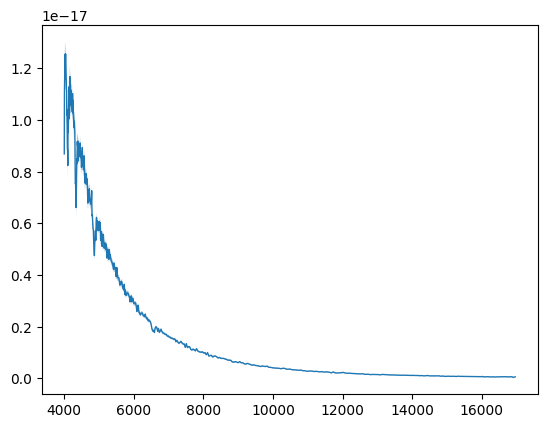

In [6]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

# noise already applied to flux (realistic)
ax.plot(lbda, flux, lw=1)
ax.fill_between(lbda, 
                flux+np.sqrt(variance), 
                flux-np.sqrt(variance), alpha=0.5)


## Change the detector mode

Let's first check the current configuration

In [7]:
lazuli_star.get_readout_config()

{'nmd': (64, 8, 0), 'nramp': 4}

now, say we want to reduce the maximum number of groups to 50, but having 10 frames per group.

To do so, let's specify the MACC (nmd) mode to be (1, 10, 0). 1 group (this will vary when re-calling setup_to_snr), 10 frames per group, no drop. 

In [8]:
lazuli_star.change_detector_mode(nmd=(1, 10, 0), max_group=50)
_ = lazuli_star.setup_to_snr(30, lbda_range=[4000, 7000])

In [9]:
lazuli_star.get_readout_config()

{'nmd': (50, 10, 0), 'nramp': 4}

In [10]:
lazuli_star.get_exposure_time() # this is slightly faster

5660.0

In [11]:
# and for 1 frame per group
lazuli_star.change_detector_mode(nmd=(1, 1, 0), max_group=50)
_ = lazuli_star.setup_to_snr(30, lbda_range=[4000, 7000])

In [12]:
lazuli_star.get_readout_config()

{'nmd': (50, 1, 0), 'nramp': 147}

In [13]:
lazuli_star.get_exposure_time() # this is much slower

20800.5

having only 1 frame per group with at max of 50 groups (so 50 frames), this means a lot of ramp. 
So this is badly affected by read-out noise

## Force the read-out mode

You can also manually set the read-out mode (mnd and nramp) to observe without having to setup to a given signal to noise. You will get what you will get.

Say we want an 5 ramps of nmd=(60, 4, 2)

In [14]:
lazuli_star.change_detector_mode(nmd=(60, 4, 2), nramp=5)
# don't run setup_to_snr or (ngroup, _, _) and nramp will change

In [15]:
# This is ther resulting spectrum
lbda, flux, variance = lazuli_star.get_spectrum()

Text(0.5, 0, 'wavelength [A]')

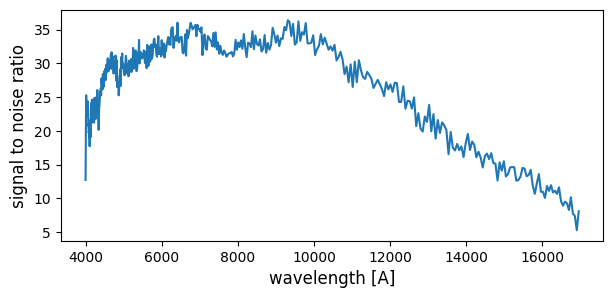

In [16]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,3))

# let's show the resulting signal to noise spectrum
ax.plot(lbda, flux/np.sqrt(variance))
ax.set_ylabel("signal to noise ratio", fontsize='large')
ax.set_xlabel("wavelength [A]", fontsize='large')

# Change the spectrograph

The Lazuli spectrograph is expected to have two sampling grids. A fine grid with ~40mas spaxels and a coarser grid with ~80mas grid. 

Smaller grid is better for resolving the PSF, but leads to a worse signal to noise. 

Use get/change_spectrograph_mode to access current configuration of change it.

In [53]:
lazuli_snia = slicersim.LazuliSN(redshift=1.3)

In [55]:
lazuli_snia.change_spectrograph_mode("fine")
detector_config, snr = lazuli_snia.setup_to_snr(20, lbda_range=[6000, 8000], frame="rest")
detector_config

{'nmd': (64, 8, 0), 'nramp': 18}

In [50]:
lazuli_star.get_exposure_time()

10142.720000000001

In [59]:
lazuli_snia.change_spectrograph_mode("medium")
detector_config, snr = lazuli_snia.setup_to_snr(20, lbda_range=[6000, 8000], frame="rest")
detector_config

{'nmd': (64, 8, 0), 'nramp': 10}

In [60]:
lazuli_snia.get_exposure_time()

14489.6

In [61]:
lazuli_snia.get_spectrograph_sampling()

('medium', {'spatial_shape': [58, 116], 'spatial_scale': 0.08})